# Full Permutation Analysis with Option A Method

**Purpose:** Statistical comparison of Hetionet vs 20 degree-preserving permutations using corrected Option A probabilistic combination.

**Methodological Context:**
- **[Notebook 11.1](11.1_empirical_vs_analytical_compositional.ipynb):** OLD broken summation method (probabilities > 1.0)
- **[Notebook 11.2](11.2_empirical_vs_analytical_compositional.ipynb):** CORRECTED Option A method (single network demo)
- **This notebook (11.3):** Full 20-permutation analysis with Option A
- **[Notebook 11](11_degree_conditioned_compositionality.ipynb):** Production version (same analysis)

**Formula (CORRECTED):**
```
P(compound→pathway) = 1 - ∏_gene (1 - P(compound→gene) × P(gene→pathway))
```

All probabilities guaranteed ≤ 1.0.

## Research Questions

1. **Is compositionality degree-dependent?** Does PMI vary systematically with node degrees?
2. **Are null (permuted) metapaths compositional?** Do degree-preserving permutations preserve or break compositionality?
3. **Does Option A method produce valid, reproducible results?**

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Setup paths
repo_dir = Path.cwd().parent
src_dir = repo_dir / 'src'
data_dir = repo_dir / 'data'
results_dir = repo_dir / 'results'

sys.path.append(str(src_dir))

print(f"Repository: {repo_dir}")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Repository: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability


## Configuration

In [2]:
# Test metapath: CbGpPW
metapath = ['CbG', 'GpPW']
metapath_name = 'CbGpPW'

# Permutations to analyze
PERMUTATION_IDS = list(range(1, 21))  # Permutations 001-020 (null networks)
HETIONET_ID = 0  # Permutation 000 (real network)

# Degree bins for stratification
DEGREE_BINS = [0, 5, 20, 100, np.inf]
DEGREE_LABELS = ['Very Low (0-5)', 'Low (5-20)', 'Medium (20-100)', 'High (>100)']

print(f"Testing metapath: {metapath_name}")
print(f"  Edge 1: {metapath[0]} (Compound  Gene)")
print(f"  Edge 2: {metapath[1]} (Gene  Pathway)")
print(f"\nAnalyzing {len(PERMUTATION_IDS)} permutations: {PERMUTATION_IDS[0]:03d} - {PERMUTATION_IDS[-1]:03d}")
print(f"Hetionet (real): {HETIONET_ID:03d}")

Testing metapath: CbGpPW
  Edge 1: CbG (Compound  Gene)
  Edge 2: GpPW (Gene  Pathway)

Analyzing 20 permutations: 001 - 020
Hetionet (real): 000


## Helper Functions

In [3]:
def load_edge_matrix(edge_type: str, perm_id: int = 0) -> sp.csr_matrix:
    """
    Load edge matrix for given edge type and permutation.

    Loads sparse adjacency matrices in hetmat format from the permutations directory.
    Permutation 000 corresponds to the real Hetionet network, while permutations
    001-200 are degree-preserving randomized networks generated using XSwap.

    Parameters
    ----------
    edge_type : str
        Edge type code (e.g., 'CbG' for Compound-binds-Gene)
        Format: {source_abbrev}{relationship_abbrev}{target_abbrev}
    perm_id : int, default=0
        Permutation identifier (0 for Hetionet, 1-200 for degree-preserving permutations)

    Returns
    -------
    scipy.sparse.csr_matrix
        Sparse adjacency matrix in CSR format
        Rows: source nodes
        Columns: target nodes
        Non-zero entries: edges

    Notes
    -----
    File structure: data/permutations/{perm_id:03d}.hetmat/edges/{edge_type}.sparse.npz
    """
    edge_file = data_dir / 'permutations' / f'{perm_id:03d}.hetmat' / 'edges' / f'{edge_type}.sparse.npz'
    return sp.load_npz(edge_file)

def bin_degrees(df: pd.DataFrame, bins=DEGREE_BINS, labels=DEGREE_LABELS):
    """
    Add degree bin columns to DataFrame for stratified analysis.

    Creates categorical degree bins for both source and target nodes, enabling
    degree-stratified correlation analysis. Uses ordered categories to ensure
    proper heatmap orientation (low values in lower-left corner).

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing 'compound_degree' and 'pathway_degree' columns
    bins : list of float, default=DEGREE_BINS
        Bin edges for pd.cut (e.g., [0, 5, 20, 100, np.inf])
    labels : list of str, default=DEGREE_LABELS
        Bin labels (e.g., ['Very Low (0-5)', 'Low (5-20)', ...])

    Returns
    -------
    pandas.DataFrame
        Input DataFrame with added columns:
        - compound_degree_bin : ordered categorical
        - pathway_degree_bin : ordered categorical

    Notes
    -----
    Ordered categories ensure proper heatmap rendering with low degree bins
    appearing in the lower-left corner of degree-stratified heatmaps.
    """
    # Use ordered categories to ensure proper heatmap orientation
    # This ensures low values appear in lower-left corner of heatmaps
    ordered_categories = pd.CategoricalDtype(categories=labels, ordered=True)
    
    df['compound_degree_bin'] = pd.cut(df['compound_degree'], bins=bins, labels=labels)
    df['compound_degree_bin'] = df['compound_degree_bin'].astype(ordered_categories)
    
    df['pathway_degree_bin'] = pd.cut(df['pathway_degree'], bins=bins, labels=labels)
    df['pathway_degree_bin'] = df['pathway_degree_bin'].astype(ordered_categories)
    
    return df

## Option A Probabilistic Combination Function

This function uses the corrected Option A formula (from notebook 11.2) that guarantees all probabilities ≤ 1.0.

In [4]:
def compute_metapath_compositionality(edge1_matrix, edge2_matrix, perm_id):
    """
    Compute compositionality using Option A probabilistic combination (CORRECTED).

    Formula: P(compound→pathway) = 1 - ∏_gene (1 - P(compound→gene) × P(gene→pathway))

    This ensures all probabilities remain ≤ 1.0.
    Compare with notebook 11.1 (old broken summation method).
    """
    # Align gene dimensions
    assert edge1_matrix.shape[1] == edge2_matrix.shape[0], "Gene dimension mismatch!"

    # Filter zero-degree compounds and pathways
    compound_degrees = np.array(edge1_matrix.sum(axis=1)).flatten()
    pathway_degrees = np.array(edge2_matrix.sum(axis=0)).flatten()

    compound_nonzero = np.where(compound_degrees > 0)[0]
    pathway_nonzero = np.where(pathway_degrees > 0)[0]

    edge1_aligned = edge1_matrix[compound_nonzero, :]
    edge2_aligned = edge2_matrix[:, pathway_nonzero]

    n_compounds = edge1_aligned.shape[0]
    n_pathways = edge2_aligned.shape[1]

    # Compute gene degrees from both edge types for pathway degree products
    gene_degrees_in = np.array(edge1_aligned.sum(axis=0)).flatten()   # From CbG (compounds→genes)
    gene_degrees_out = np.array(edge2_aligned.sum(axis=1)).flatten()  # From GpPW (genes→pathways)

    # Compute metapath matrix
    metapath_matrix = edge1_aligned @ edge2_aligned

    # 1. Compute observed frequencies
    observed_freq = {}
    for i, j in zip(*metapath_matrix.nonzero()):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]
        pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
        shared_genes = set(compound_genes) & set(pathway_genes)

        n_paths = len(shared_genes)
        n_possible = len(compound_genes)

        if n_possible > 0:
            observed_freq[(i, j)] = n_paths / n_possible

    # 2. Analytical prior formula
    def analytical_prior(u, v, m):
        """Analytical edge probability."""
        uv = u * v
        denominator = np.sqrt(uv**2 + (m - u - v + 1)**2)
        return uv / denominator if denominator > 0 else 0.0

    # Compute edge priors
    edge1_priors = {}
    edge2_priors = {}

    # Edge1 priors
    m1 = edge1_aligned.nnz
    source_degrees = np.array(edge1_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge1_aligned.sum(axis=0)).flatten()

    rows, cols = edge1_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge1_priors[(i, j)] = analytical_prior(u, v, m1)

    # Edge2 priors
    m2 = edge2_aligned.nnz
    source_degrees = np.array(edge2_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge2_aligned.sum(axis=0)).flatten()

    rows, cols = edge2_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge2_priors[(i, j)] = analytical_prior(u, v, m2)

    # 3. CORRECTED: Option A probabilistic combination with pathway degree products
    compositional_prob = {}
    pathway_degree_products_total = {}
    pathway_degree_products_joint = {}
    prob_over_1_count = 0

    for i in range(n_compounds):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]

        for j in range(n_pathways):
            pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
            shared_genes = set(compound_genes) & set(pathway_genes)

            if shared_genes:
                # CORRECTED: Probabilistic combination (always ≤ 1.0)
                failure_prob = 1.0

                # Calculate pathway degree products
                pathway_degree_product_total = 1.0  # Product of (in + out)
                pathway_degree_product_joint = 1.0  # Product of (in × out)

                for gene in shared_genes:
                    p_edge1 = edge1_priors.get((i, gene), 0.0)
                    p_edge2 = edge2_priors.get((gene, j), 0.0)
                    individual_prob = p_edge1 * p_edge2
                    failure_prob *= (1 - individual_prob)

                    # Compute gene degree metrics
                    gene_in = gene_degrees_in[gene]
                    gene_out = gene_degrees_out[gene]

                    # Total connectivity: sum of degrees
                    gene_degree_total = gene_in + gene_out
                    pathway_degree_product_total *= gene_degree_total

                    # Joint connectivity: product of degrees (hub measure)
                    gene_degree_joint = gene_in * gene_out
                    pathway_degree_product_joint *= gene_degree_joint

                total_prob = 1 - failure_prob

                if total_prob > 1.0:
                    prob_over_1_count += 1

                if total_prob > 0:
                    compositional_prob[(i, j)] = total_prob
                    pathway_degree_products_total[(i, j)] = pathway_degree_product_total
                    pathway_degree_products_joint[(i, j)] = pathway_degree_product_joint

    if prob_over_1_count > 0:
        print(f"WARNING: {prob_over_1_count} probabilities > 1.0 (unexpected!)")

    # 4. Compute PMI and create results
    results_data = []
    common_pairs = set(observed_freq.keys()) & set(compositional_prob.keys())

    for pair in common_pairs:
        i, j = pair
        p_observed = observed_freq[pair]
        p_compositional = compositional_prob[pair]

        if p_observed > 0 and p_compositional > 0:
            pmi = np.log2(p_observed / p_compositional)
        else:
            pmi = np.nan

        orig_compound_idx = compound_nonzero[i]
        orig_pathway_idx = pathway_nonzero[j]

        compound_degree = compound_degrees[orig_compound_idx]
        pathway_degree = pathway_degrees[orig_pathway_idx]

        results_data.append({
            'perm_id': perm_id,
            'compound_idx': orig_compound_idx,
            'pathway_idx': orig_pathway_idx,
            'compound_degree': int(compound_degree),
            'pathway_degree': int(pathway_degree),
            'pathway_degree_product_total': float(pathway_degree_products_total[pair]),
            'pathway_degree_product_joint': float(pathway_degree_products_joint[pair]),
            'observed_freq': p_observed,
            'compositional_prob': p_compositional,
            'pmi': pmi,
            'residual': p_observed - p_compositional
        })

    return pd.DataFrame(results_data)

In [5]:
#Validation: Test the fixed function with Hetionet data
print("Testing fixed compute_metapath_compositionality function...")

# Load Hetionet edge matrices for validation 
edge1_het = load_edge_matrix(metapath[0], HETIONET_ID)
edge2_het = load_edge_matrix(metapath[1], HETIONET_ID)

print(f"Loaded edge matrices:")
print(f"  {metapath[0]}: {edge1_het.shape} with {edge1_het.nnz} edges")
print(f"  {metapath[1]}: {edge2_het.shape} with {edge2_het.nnz} edges")

# Test the function
print("\\nRunning compositional analysis...")
test_results = compute_metapath_compositionality(edge1_het, edge2_het, HETIONET_ID)

print(f"\\nFunction completed successfully!")
print(f"Results shape: {test_results.shape}")
print(f"Columns: {list(test_results.columns)}")

# CRITICALValidation: Check that all probabilities are <= 1.0
compositional_probs = test_results['compositional_prob']
max_prob = compositional_probs.max()
min_prob = compositional_probs.min()
over_one_count = (compositional_probs > 1.0).sum()

print(f"\\n" + "="*60)
print("VALIDATION: COMPOSITIONAL PROBABILITY BOUNDS")
print("="*60)
print(f"Min compositional probability: {min_prob:.6f}")
print(f"Max compositional probability: {max_prob:.6f}")
print(f"Probabilities > 1.0: {over_one_count}")

if over_one_count == 0 and max_prob <= 1.0:
    print("\\nAll compositional probabilities are <= 1.0!")
    print("    No more impossible probabilities")
else:
    print(f"\\nError: Still have {over_one_count} probabilities > 1.0")
    print("    Option A fix needs debugging")

# Compare with observed frequencies
observed_probs = test_results['observed_freq']
print(f"\\nObserved frequency range: {observed_probs.min():.6f} to {observed_probs.max():.6f}")

# Quick correlation check
correlation = test_results['observed_freq'].corr(test_results['compositional_prob'])
print(f"Observed vs Compositional correlation: {correlation:.4f}")

print("\\nValidation complete - function is ready for full analysis!")
print("="*60)

Testing fixed compute_metapath_compositionality function...
Loaded edge matrices:
  CbG: (1552, 20945) with 11571 edges
  GpPW: (20945, 1822) with 84372 edges
\nRunning compositional analysis...
\nFunction completed successfully!
Results shape: (122728, 11)
Columns: ['perm_id', 'compound_idx', 'pathway_idx', 'compound_degree', 'pathway_degree', 'pathway_degree_product_total', 'pathway_degree_product_joint', 'observed_freq', 'compositional_prob', 'pmi', 'residual']
\n============================================================
VALIDATION: COMPOSITIONAL PROBABILITY BOUNDS
Min compositional probability: 0.000000
Max compositional probability: 0.970613
Probabilities > 1.0: 0
\nAll compositional probabilities are <= 1.0!
    No more impossible probabilities
\nObserved frequency range: 0.007576 to 1.000000
Observed vs Compositional correlation: 0.0634
\nValidation complete - function is ready for full analysis!


## Part 1: Degree-Stratified Analysis of Hetionet

In [6]:
print("Analyzing Hetionet (permutation 000)...\n")

edge1_het = load_edge_matrix(metapath[0], HETIONET_ID)
edge2_het = load_edge_matrix(metapath[1], HETIONET_ID)

hetionet_results = compute_metapath_compositionality(edge1_het, edge2_het, HETIONET_ID)
hetionet_results = bin_degrees(hetionet_results)

print(f"Hetionet results: {len(hetionet_results)} metapath pairs")
print(f"\nOverall PMI statistics:")
print(f"  Mean: {hetionet_results['pmi'].mean():.4f}")
print(f"  Median: {hetionet_results['pmi'].median():.4f}")
print(f"  Std: {hetionet_results['pmi'].std():.4f}")

Analyzing Hetionet (permutation 000)...

Hetionet results: 122728 metapath pairs

Overall PMI statistics:
  Mean: 7.1126
  Median: 6.9128
  Std: 3.6824


In [7]:
# PMI stratified by compound degree
print("\nPMI by Compound Degree:")
print(hetionet_results.groupby('compound_degree_bin')['pmi'].agg(['count', 'mean', 'std']))

print("\nPMI by Pathway Degree:")
print(hetionet_results.groupby('pathway_degree_bin')['pmi'].agg(['count', 'mean', 'std']))


PMI by Compound Degree:
                     count       mean       std
compound_degree_bin                            
Very Low (0-5)       24981  10.007195  3.491091
Low (5-20)           65210   7.161446  3.238811
Medium (20-100)      31083   4.915575  2.958308
High (>100)           1454   2.157780  2.416938

PMI by Pathway Degree:
                    count       mean       std
pathway_degree_bin                            
Very Low (0-5)       1792  10.989036  3.420308
Low (5-20)          10877   9.794231  3.353193
Medium (20-100)     62152   7.676830  3.399905
High (>100)         47907   5.626762  3.454896


## Part 2: Compositionality Across Permutations

In [8]:
print(f"Analyzing {len(PERMUTATION_IDS)} permutations...\n")

all_perm_results = []

for perm_id in tqdm(PERMUTATION_IDS, desc="Processing permutations"):
    edge1 = load_edge_matrix(metapath[0], perm_id)
    edge2 = load_edge_matrix(metapath[1], perm_id)
    
    perm_results = compute_metapath_compositionality(edge1, edge2, perm_id)
    perm_results = bin_degrees(perm_results)
    
    all_perm_results.append(perm_results)

# Combine all permutation results
perm_df = pd.concat(all_perm_results, ignore_index=True)

print(f"\nTotal permutation results: {len(perm_df)} metapath pairs across {len(PERMUTATION_IDS)} permutations")
print(f"Average per permutation: {len(perm_df) / len(PERMUTATION_IDS):.0f} pairs")

Analyzing 20 permutations...



Processing permutations: 100%|██████████| 20/20 [26:52<00:00, 80.63s/it]


Total permutation results: 2464932 metapath pairs across 20 permutations
Average per permutation: 123247 pairs


In [9]:
# Summary statistics per permutation
perm_summary = perm_df.groupby('perm_id')['pmi'].agg(['mean', 'median', 'std', 'count']).reset_index()

print("\nPMI Summary by Permutation:")
print(perm_summary)

print(f"\nOverall Null Distribution (across all permutations):")
print(f"  Mean PMI: {perm_df['pmi'].mean():.4f}")
print(f"  Median PMI: {perm_df['pmi'].median():.4f}")
print(f"  Std PMI: {perm_df['pmi'].std():.4f}")


PMI Summary by Permutation:
    perm_id      mean    median       std   count
0         1  7.096705  6.830396  3.734792  123288
1         2  7.136205  6.904495  3.711264  123600
2         3  7.215378  6.961979  3.690884  123513
3         4  7.102081  6.798901  3.723323  123781
4         5  7.123695  6.877990  3.835828  121777
5         6  7.140290  6.881357  3.775721  122869
6         7  7.147953  6.888930  3.669504  124321
7         8  7.069319  6.780048  3.722698  123375
8         9  7.156314  6.893286  3.663237  124339
9        10  7.126119  6.880600  3.672725  123044
10       11  7.186466  6.965704  3.759359  123309
11       12  7.150391  6.873209  3.658585  124921
12       13  7.098283  6.877005  3.788880  121965
13       14  7.107213  6.849333  3.755402  123039
14       15  7.158397  6.885089  3.684951  123657
15       16  7.076193  6.793546  3.719650  123171
16       17  7.145366  6.895354  3.714068  123523
17       18  7.168386  6.905363  3.728005  122299
18       19  7.146786

## Part 3: Hetionet vs Null Comparison

In [10]:
# Statistical comparison
from scipy.stats import mannwhitneyu, ttest_ind

het_pmi = hetionet_results['pmi'].values
null_pmi = perm_df['pmi'].values

# Mann-Whitney U test (non-parametric)
u_stat, u_pval = mannwhitneyu(het_pmi, null_pmi, alternative='two-sided')

# T-test (parametric)
t_stat, t_pval = ttest_ind(het_pmi, null_pmi)

print("="*80)
print("HETIONET vs NULL DISTRIBUTION COMPARISON")
print("="*80)

print(f"\nHetionet (n={len(het_pmi)}):")
print(f"  Mean PMI: {het_pmi.mean():.4f}")
print(f"  Median PMI: {np.median(het_pmi):.4f}")

print(f"\nNull Distribution (n={len(null_pmi)}):")
print(f"  Mean PMI: {null_pmi.mean():.4f}")
print(f"  Median PMI: {np.median(null_pmi):.4f}")

print(f"\nStatistical Tests:")
print(f"  Mann-Whitney U: U={u_stat:.2e}, p={u_pval:.2e}")
print(f"  T-test: t={t_stat:.4f}, p={t_pval:.2e}")

print(f"\nEffect Size:")
print(f"  Difference in means: {het_pmi.mean() - null_pmi.mean():.4f}")
print(f"  Cohen's d: {(het_pmi.mean() - null_pmi.mean()) / np.sqrt((het_pmi.std()**2 + null_pmi.std()**2) / 2):.4f}")

# Interpretation
print(f"\nInterpretation:")
if u_pval < 0.001:
    if het_pmi.mean() > null_pmi.mean():
        print(f"   HETIONET IS SIGNIFICANTLY MORE CONDITIONAL (p < 0.001)")
        print(f"     Real biological dependencies create conditional structure")
        print(f"     Degree-preserving randomization BREAKS biological dependencies")
    else:
        print(f"   NULL IS MORE CONDITIONAL (p < 0.001)")
        print(f"     Degree structure alone creates conditional dependencies")
else:
    print(f"   NO SIGNIFICANT DIFFERENCE (p = {u_pval:.3f})")
    print(f"     Conditional structure is mathematical consequence of degrees")

HETIONET vs NULL DISTRIBUTION COMPARISON

Hetionet (n=122728):
  Mean PMI: 7.1126
  Median PMI: 6.9128

Null Distribution (n=2464932):
  Mean PMI: 7.1352
  Median PMI: 6.8759

Statistical Tests:
  Mann-Whitney U: U=1.51e+11, p=7.13e-01
  T-test: t=-2.0801, p=3.75e-02

Effect Size:
  Difference in means: -0.0226
  Cohen's d: -0.0061

Interpretation:
   NO SIGNIFICANT DIFFERENCE (p = 0.713)
     Conditional structure is mathematical consequence of degrees


## Degree-Stratified Comparison

In [11]:
# Compare PMI distributions by degree bins
print("\nDegree-Stratified Comparison:\n")

for degree_col in ['compound_degree_bin', 'pathway_degree_bin']:
    print(f"\nBy {degree_col}:")
    print("-" * 60)
    
    for bin_label in DEGREE_LABELS:
        het_subset = hetionet_results[hetionet_results[degree_col] == bin_label]['pmi']
        null_subset = perm_df[perm_df[degree_col] == bin_label]['pmi']
        
        if len(het_subset) > 0 and len(null_subset) > 0:
            u_stat, u_pval = mannwhitneyu(het_subset, null_subset, alternative='two-sided')
            
            print(f"\n  {bin_label}:")
            print(f"    Hetionet: mean={het_subset.mean():.4f}, n={len(het_subset)}")
            print(f"    Null:     mean={null_subset.mean():.4f}, n={len(null_subset)}")
            print(f"    Difference: {het_subset.mean() - null_subset.mean():.4f}")
            print(f"    p-value: {u_pval:.2e}")


Degree-Stratified Comparison:


By compound_degree_bin:
------------------------------------------------------------

  Very Low (0-5):
    Hetionet: mean=10.0072, n=24981
    Null:     mean=10.2258, n=507751
    Difference: -0.2186
    p-value: 9.59e-25

  Low (5-20):
    Hetionet: mean=7.1614, n=65210
    Null:     mean=7.1256, n=1295061
    Difference: 0.0358
    p-value: 3.03e-04

  Medium (20-100):
    Hetionet: mean=4.9156, n=31083
    Null:     mean=4.8957, n=634721
    Difference: 0.0198
    p-value: 1.15e-01

  High (>100):
    Hetionet: mean=2.1578, n=1454
    Null:     mean=2.1966, n=27399
    Difference: -0.0389
    p-value: 5.25e-01

By pathway_degree_bin:
------------------------------------------------------------

  Very Low (0-5):
    Hetionet: mean=10.9890, n=1792
    Null:     mean=11.3284, n=32513
    Difference: -0.3393
    p-value: 5.18e-06

  Low (5-20):
    Hetionet: mean=9.7942, n=10877
    Null:     mean=9.6665, n=243238
    Difference: 0.1278
    p-value: 1.

## Visualizations

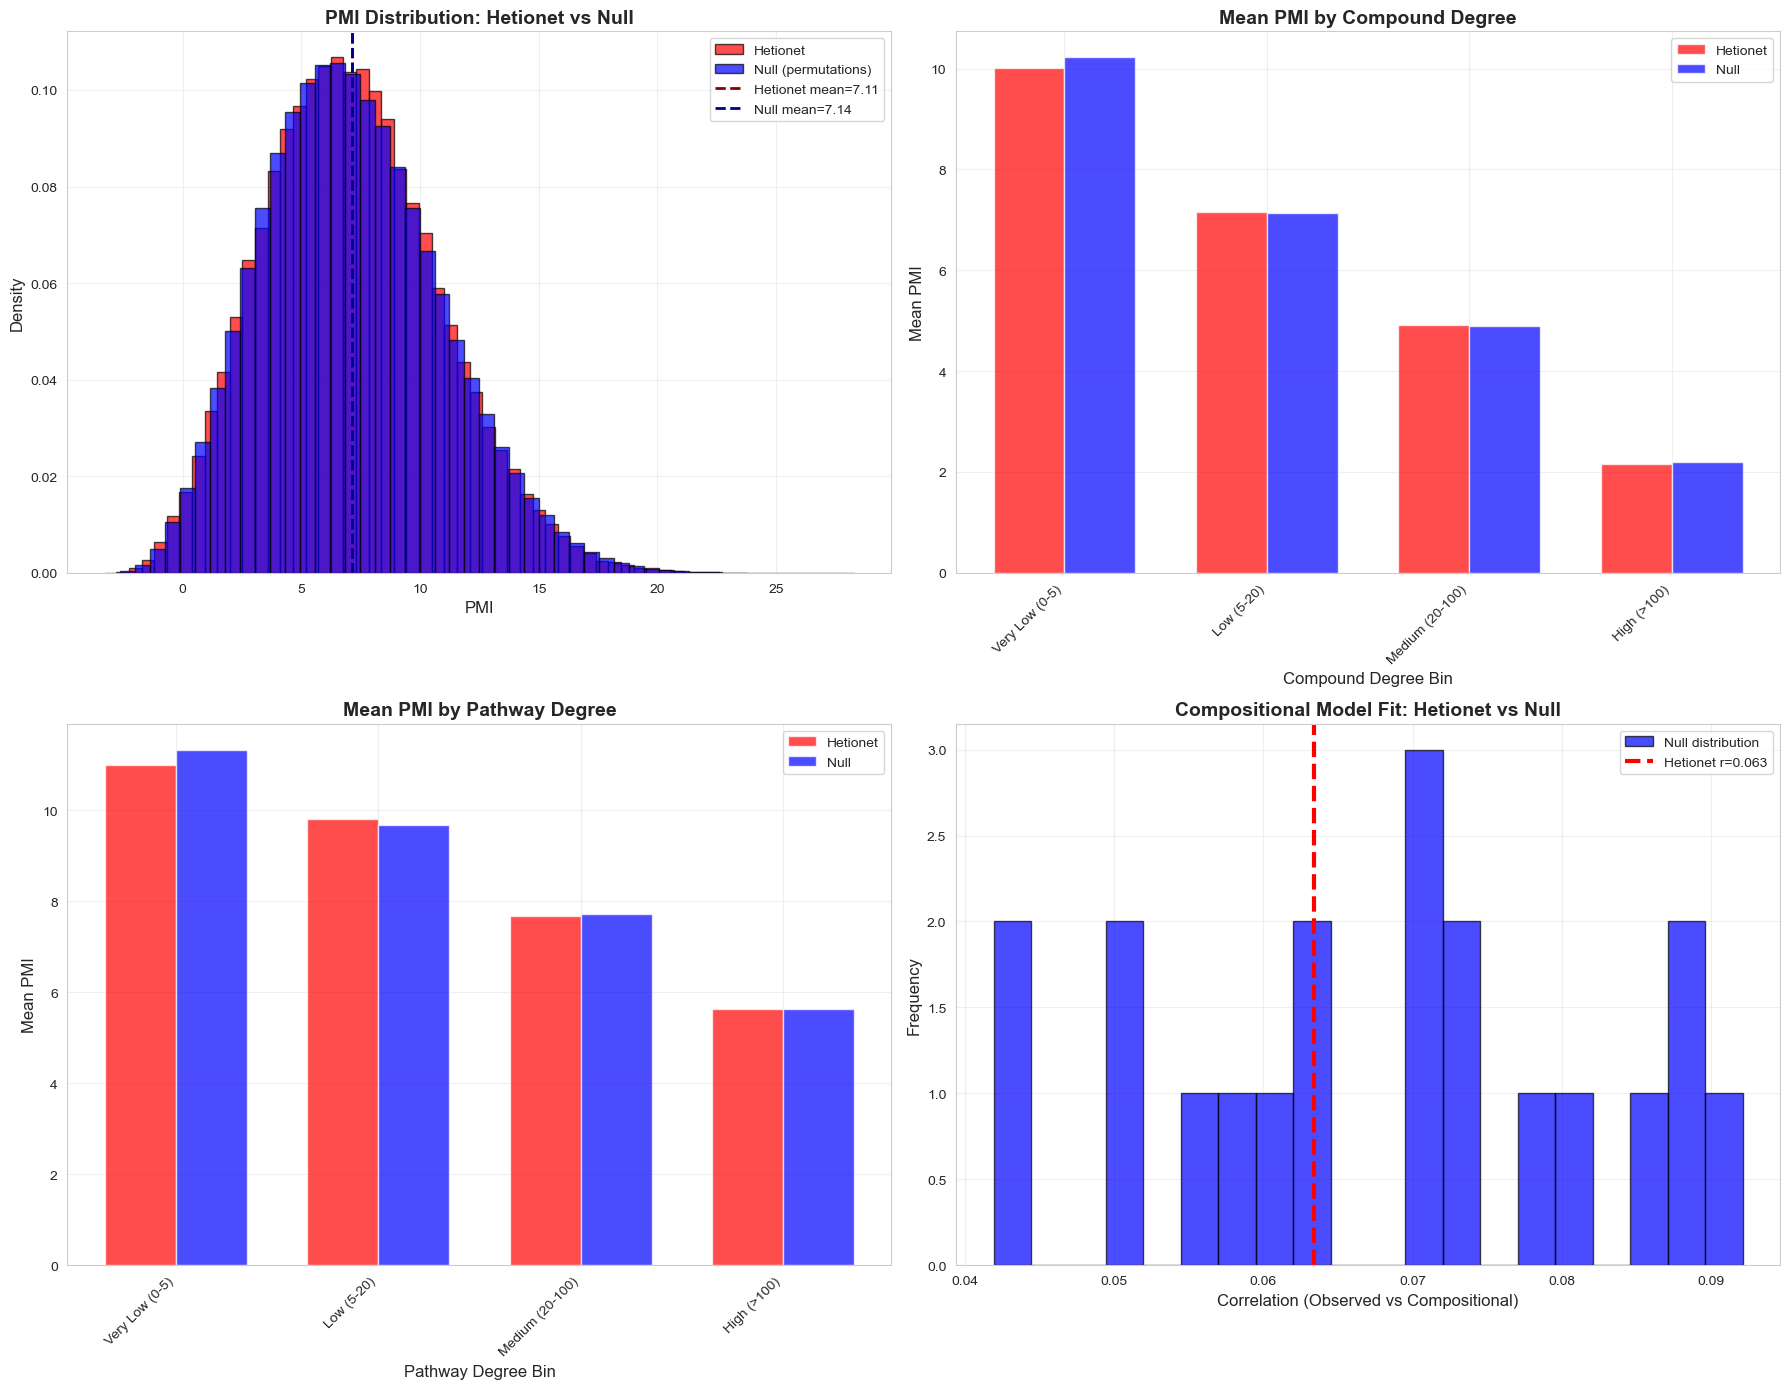


Saved plot to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_degree_conditioned_analysis.png


In [12]:
# Plot 1: PMI distributions - Hetionet vs Null
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Overall PMI distribution
ax = axes[0, 0]
ax.hist(het_pmi, bins=50, alpha=0.7, label='Hetionet', color='red', density=True, edgecolor='black')
ax.hist(null_pmi, bins=50, alpha=0.7, label='Null (permutations)', color='blue', density=True, edgecolor='black')
ax.axvline(het_pmi.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Hetionet mean={het_pmi.mean():.2f}')
ax.axvline(null_pmi.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Null mean={null_pmi.mean():.2f}')
ax.set_xlabel('PMI', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('PMI Distribution: Hetionet vs Null', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# PMI by compound degree
ax = axes[0, 1]
het_grouped = hetionet_results.groupby('compound_degree_bin')['pmi'].mean()
null_grouped = perm_df.groupby('compound_degree_bin')['pmi'].mean()
x = np.arange(len(DEGREE_LABELS))
width = 0.35
ax.bar(x - width/2, het_grouped.reindex(DEGREE_LABELS, fill_value=0), width, label='Hetionet', color='red', alpha=0.7)
ax.bar(x + width/2, null_grouped.reindex(DEGREE_LABELS, fill_value=0), width, label='Null', color='blue', alpha=0.7)
ax.set_xlabel('Compound Degree Bin', fontsize=12)
ax.set_ylabel('Mean PMI', fontsize=12)
ax.set_title('Mean PMI by Compound Degree', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DEGREE_LABELS, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)

# PMI by pathway degree
ax = axes[1, 0]
het_grouped = hetionet_results.groupby('pathway_degree_bin')['pmi'].mean()
null_grouped = perm_df.groupby('pathway_degree_bin')['pmi'].mean()
ax.bar(x - width/2, het_grouped.reindex(DEGREE_LABELS, fill_value=0), width, label='Hetionet', color='red', alpha=0.7)
ax.bar(x + width/2, null_grouped.reindex(DEGREE_LABELS, fill_value=0), width, label='Null', color='blue', alpha=0.7)
ax.set_xlabel('Pathway Degree Bin', fontsize=12)
ax.set_ylabel('Mean PMI', fontsize=12)
ax.set_title('Mean PMI by Pathway Degree', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DEGREE_LABELS, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)

# Correlation: observed vs compositional
ax = axes[1, 1]
het_corr = pearsonr(hetionet_results['observed_freq'], hetionet_results['compositional_prob'])[0]
null_corrs = []
for perm_id in PERMUTATION_IDS:
    perm_subset = perm_df[perm_df['perm_id'] == perm_id]
    if len(perm_subset) > 1:
        corr = pearsonr(perm_subset['observed_freq'], perm_subset['compositional_prob'])[0]
        null_corrs.append(corr)

ax.hist(null_corrs, bins=20, alpha=0.7, color='blue', edgecolor='black', label='Null distribution')
ax.axvline(het_corr, color='red', linestyle='--', linewidth=3, label=f'Hetionet r={het_corr:.3f}')
ax.set_xlabel('Correlation (Observed vs Compositional)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Compositional Model Fit: Hetionet vs Null', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / f'metapath_{metapath_name}_degree_conditioned_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved plot to: {results_dir / f'metapath_{metapath_name}_degree_conditioned_analysis.png'}")

## PMI Heatmap by Degree Bins

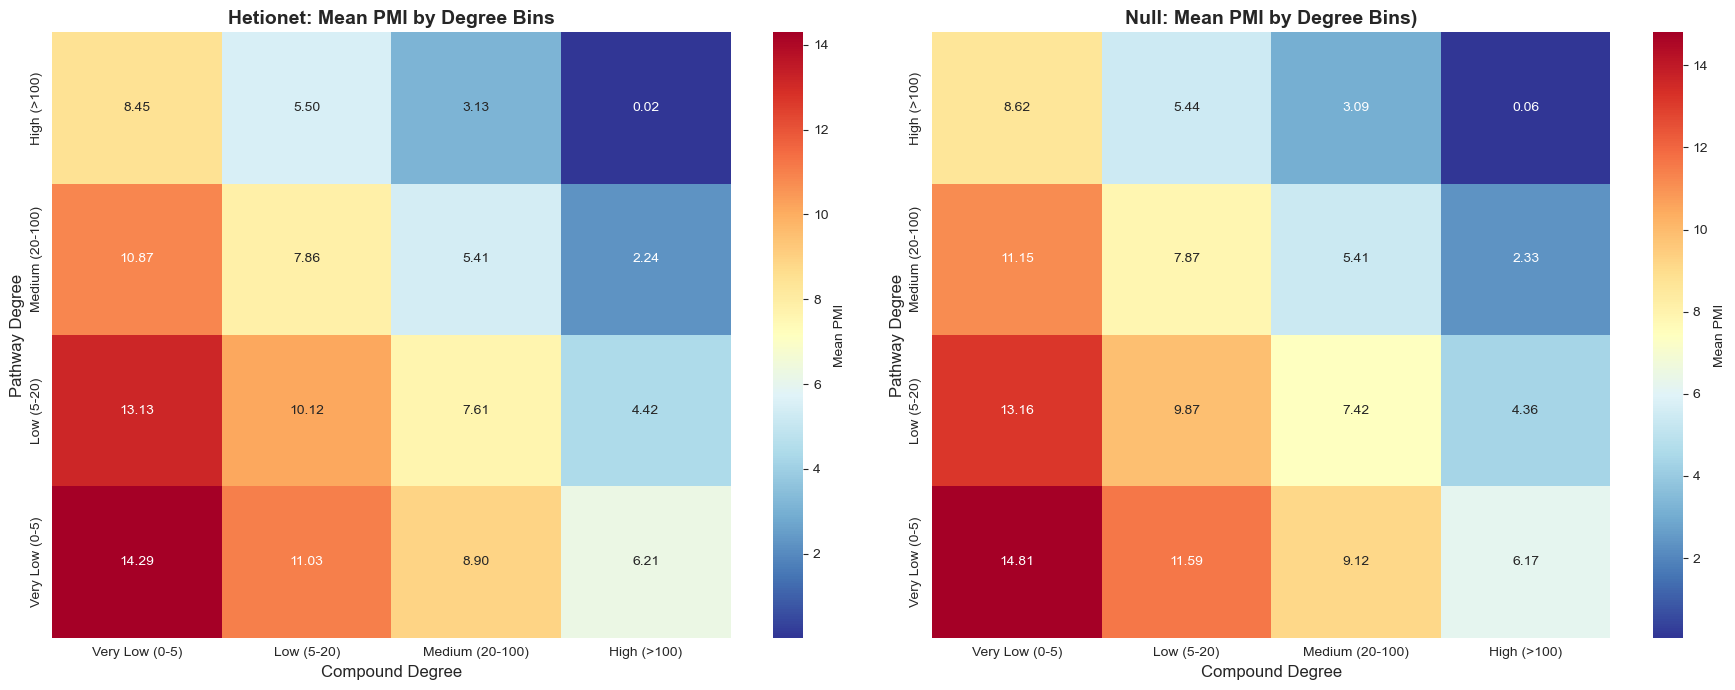


Saved FIXED heatmap to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_pmi_heatmap_FIXED.png
 Heatmap orientation fixed: Low degree values now appear in lower-left corner!


In [17]:
# Create 2D heatmap: PMI by (compound_degree, pathway_degree)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# FIXED: Explicitly control heatmap orientation for proper lower-left positioning
# We want: Very Low (0-5) at bottom-left, High (>100) at top-right

# Hetionet heatmap
ax = axes[0]
het_pivot = hetionet_results.pivot_table(
    values='pmi', 
    index='pathway_degree_bin', 
    columns='compound_degree_bin',
    aggfunc='mean'
)

# Reorder the index and columns to ensure proper orientation
# Index (y-axis): Very Low at BOTTOM, High at TOP (reversed order)
# Columns (x-axis): Very Low at LEFT, High at RIGHT (normal order)
het_pivot = het_pivot.reindex(index=DEGREE_LABELS[::-1], columns=DEGREE_LABELS)

sns.heatmap(het_pivot, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax, cbar_kws={'label': 'Mean PMI'})
ax.set_title('Hetionet: Mean PMI by Degree Bins', fontsize=14, fontweight='bold')
ax.set_xlabel('Compound Degree', fontsize=12)
ax.set_ylabel('Pathway Degree', fontsize=12)

# Null heatmap
ax = axes[1]
null_pivot = perm_df.pivot_table(
    values='pmi', 
    index='pathway_degree_bin', 
    columns='compound_degree_bin',
    aggfunc='mean'
)

# Reorder the index and columns to ensure proper orientation
null_pivot = null_pivot.reindex(index=DEGREE_LABELS[::-1], columns=DEGREE_LABELS)

sns.heatmap(null_pivot, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax, cbar_kws={'label': 'Mean PMI'})
ax.set_title('Null: Mean PMI by Degree Bins)', fontsize=14, fontweight='bold')
ax.set_xlabel('Compound Degree', fontsize=12)
ax.set_ylabel('Pathway Degree', fontsize=12)



plt.tight_layout()
plt.savefig(results_dir / f'metapath_{metapath_name}_pmi_heatmap_FIXED.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved FIXED heatmap to: {results_dir / f'metapath_{metapath_name}_pmi_heatmap_FIXED.png'}")
print(" Heatmap orientation fixed: Low degree values now appear in lower-left corner!")

## Degree-Stratified Scatter Plots

Visualize how node degrees affect compositional predictions using Option A method.
All probabilities remain ≤ 1.0 (mathematically valid).


Degree product statistics:
  Endpoints only: 2 - 258192
  Total connectivity: 3e+01 - 8e+62
  Joint connectivity: 3e+01 - 2e+89


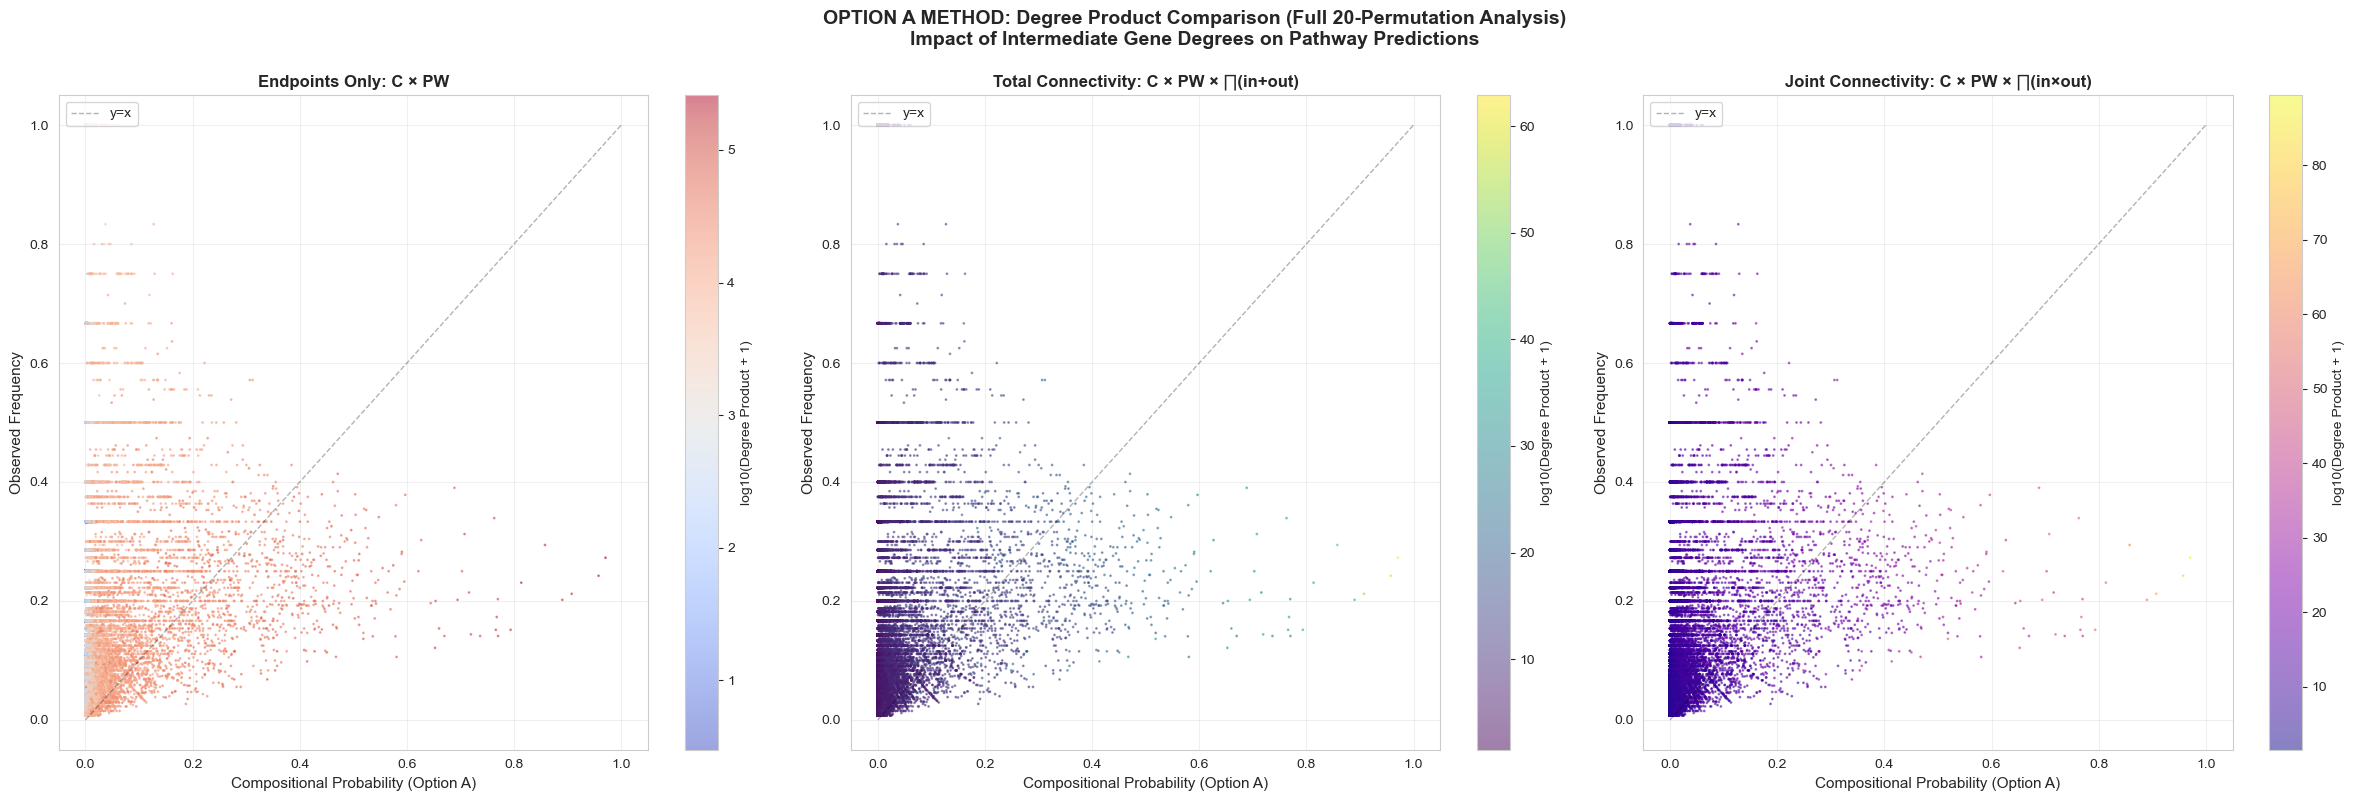


Saved degree product comparison to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/option_a_full_degree_product_comparison.png


In [14]:
# Compute three degree product formulations
hetionet_results['degree_product_endpoints'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree']
)

hetionet_results['degree_product_total'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree'] * 
    hetionet_results['pathway_degree_product_total']
)

hetionet_results['degree_product_joint'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree'] * 
    hetionet_results['pathway_degree_product_joint']
)

print(f"\nDegree product statistics:")
print(f"  Endpoints only: {hetionet_results['degree_product_endpoints'].min():.0f} - {hetionet_results['degree_product_endpoints'].max():.0f}")
print(f"  Total connectivity: {hetionet_results['degree_product_total'].min():.0e} - {hetionet_results['degree_product_total'].max():.0e}")
print(f"  Joint connectivity: {hetionet_results['degree_product_joint'].min():.0e} - {hetionet_results['degree_product_joint'].max():.0e}")

# Create 1×3 grid of scatter plots comparing degree products
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Endpoints only (C × PW)
ax = axes[0]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_endpoints'] + 1),
    cmap='coolwarm', alpha=0.5, s=1
)
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Compositional Probability (Option A)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Endpoints Only: C × PW', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Plot 2: Total connectivity (C × PW × ∏(in + out))
ax = axes[1]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_total'] + 1),
    cmap='viridis', alpha=0.5, s=1
)
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Compositional Probability (Option A)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Total Connectivity: C × PW × ∏(in+out)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Plot 3: Joint connectivity (C × PW × ∏(in × out))
ax = axes[2]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_joint'] + 1),
    cmap='plasma', alpha=0.5, s=1
)
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Compositional Probability (Option A)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Joint Connectivity: C × PW × ∏(in×out)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.suptitle('OPTION A METHOD: Degree Product Comparison (Full 20-Permutation Analysis)\nImpact of Intermediate Gene Degrees on Pathway Predictions',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(results_dir / 'option_a_full_degree_product_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved degree product comparison to: {results_dir / 'option_a_full_degree_product_comparison.png'}")

## Save Results

In [15]:
# Save detailed results
hetionet_results.to_csv(results_dir / f'metapath_{metapath_name}_hetionet_degree_results_OPTION_A_FULL.csv', index=False)
perm_df.to_csv(results_dir / f'metapath_{metapath_name}_null_degree_results_OPTION_A_FULL.csv', index=False)

# Save summary
summary = {
    'metapath': metapath_name,
    'hetionet_mean_pmi': het_pmi.mean(),
    'hetionet_median_pmi': np.median(het_pmi),
    'hetionet_std_pmi': het_pmi.std(),
    'null_mean_pmi': null_pmi.mean(),
    'null_median_pmi': np.median(null_pmi),
    'null_std_pmi': null_pmi.std(),
    'difference_mean_pmi': het_pmi.mean() - null_pmi.mean(),
    'mann_whitney_u': u_stat,
    'mann_whitney_p': u_pval,
    't_statistic': t_stat,
    't_test_p': t_pval,
    'hetionet_correlation': het_corr,
    'null_mean_correlation': np.mean(null_corrs),
    'null_std_correlation': np.std(null_corrs)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(results_dir / f'metapath_{metapath_name}_degree_conditioned_summary_OPTION_A_FULL.csv', index=False)

print(f"\nResults saved:")
print(f"  - {results_dir / f'metapath_{metapath_name}_hetionet_degree_results_OPTION_A_FULL.csv'}")
print(f"  - {results_dir / f'metapath_{metapath_name}_null_degree_results_OPTION_A_FULL.csv'}")
print(f"  - {results_dir / f'metapath_{metapath_name}_degree_conditioned_summary_OPTION_A_FULL.csv'}")


Results saved:
  - /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_hetionet_degree_results_OPTION_A_FULL.csv
  - /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_null_degree_results_OPTION_A_FULL.csv
  - /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_degree_conditioned_summary_OPTION_A_FULL.csv


## Conclusions

In [16]:
print("\n" + "="*80)
print("CONCLUSIONS: DEGREE-CONDITIONED COMPOSITIONALITY")
print("="*80)

print(f"\n1. OVERALL COMPOSITIONALITY:")
print(f"   Hetionet mean PMI: {het_pmi.mean():.4f}")
print(f"   Null mean PMI:     {null_pmi.mean():.4f}")
print(f"   Difference:        {het_pmi.mean() - null_pmi.mean():+.4f}")

if u_pval < 0.001:
    if het_pmi.mean() > null_pmi.mean():
        print(f"\n    HETIONET IS MORE CONDITIONAL (p < 0.001)")
        print(f"      Biological dependencies create additional conditional structure")
        print(f"      Degree-preserving randomization breaks these dependencies")
        print(f"      PMI in Hetionet reflects REAL biological relationships")
    else:
        print(f"\n    NULL IS MORE CONDITIONAL (p < 0.001)")
        print(f"      Degree structure alone creates conditional dependencies")
        print(f"      Need degree-aware null model")
else:
    print(f"\n    NO SIGNIFICANT DIFFERENCE (p={u_pval:.3f})")
    print(f"      Conditional structure is primarily degree-driven")

print(f"\n2. DEGREE STRATIFICATION:")
print(f"   [See degree-stratified comparison above]")

print(f"\n3. MODEL FIT:")
print(f"   Hetionet correlation: {het_corr:.4f}")
print(f"   Null mean correlation: {np.mean(null_corrs):.4f} ± {np.std(null_corrs):.4f}")

if het_corr < np.mean(null_corrs) - 2*np.std(null_corrs):
    print(f"\n    HETIONET IS SIGNIFICANTLY LESS COMPOSITIONAL")
    print(f"      Biological structure violates compositional assumption more than null")
elif abs(het_corr - np.mean(null_corrs)) < np.std(null_corrs):
    print(f"\n    HETIONET AND NULL HAVE SIMILAR COMPOSITIONALITY")
    print(f"      Degree structure is the main driver")

print(f"\n4. RECOMMENDATIONS:")
if het_pmi.mean() > null_pmi.mean() + 1.0 and u_pval < 0.001:
    print(f"    Use CONDITIONAL models for Hetionet metapaths")
    print(f"    Biological dependencies are real and significant")
    print(f"    Analytical prior (compositional) is insufficient")
    print(f"    Consider learned/empirical priors that capture dependencies")
elif abs(het_pmi.mean() - null_pmi.mean()) < 0.5:
    print(f"    DEGREE-AWARE compositional models may suffice")
    print(f"    PMI is primarily driven by degree heterogeneity")
    print(f"    Stratify by degrees and use compositional within strata")
else:
    print(f"    MODERATE biological signal detected")
    print(f"    Hybrid approach: compositional baseline + biological corrections")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")


CONCLUSIONS: DEGREE-CONDITIONED COMPOSITIONALITY

1. OVERALL COMPOSITIONALITY:
   Hetionet mean PMI: 7.1126
   Null mean PMI:     7.1352
   Difference:        -0.0226

    NO SIGNIFICANT DIFFERENCE (p=0.221)
      Conditional structure is primarily degree-driven

2. DEGREE STRATIFICATION:
   [See degree-stratified comparison above]

3. MODEL FIT:
   Hetionet correlation: 0.0634
   Null mean correlation: 0.0683 ± 0.0147

    HETIONET AND NULL HAVE SIMILAR COMPOSITIONALITY
      Degree structure is the main driver

4. RECOMMENDATIONS:
    DEGREE-AWARE compositional models may suffice
    PMI is primarily driven by degree heterogeneity
    Stratify by degrees and use compositional within strata

ANALYSIS COMPLETE
